# Daniel Rojo Mata
# Aprendizaje Automatizado, Tarea 2

# **PROBLEMA 2: Datos sintéticos**

Aplica regresión lineal a los datos sintéticos que se encuentran divididos en los archivos de *entre-
namiento*, *x_entrenamiento.csv* y *y_entrenamiento.csv* y los de validación *x_validacion.csv*
y *y_validacion.csv*.

Estos datos fueron contaminados con ruido gaussiano con media igual a 0 y
desviación estándar igual a 0.05. Realiza lo siguiente:

**a**. Grafica los datos de entrenamiento y de validación y comenta brevemente acerca de cómo están distribuidos.

**b**. Considera un modelo de la forma $f(x) = \theta_0 + \theta_1 · x_1 + \theta_2 · x_2$ y realiza la regresión lineal. Reporta los parámetros que encontraste usando el estimador de máxima verosimilitud y el valor del error cuadrático medio para los datos de entrenamiento y de validación.

**c**. Usa una expansión de base polinomial y entrena un modelo de regresión lineal con regularización por norma l2. Reporta los parámetros obtenidos y el error cuadrático medio para los
datos de entrenamiento y de validación.

**Opcional, +1** Considera que los parámetros $\theta_0$, $\theta_1$ y $\theta_2$ están distribuidos de acuerdo a una distribución
normal multivariante $N (0, I)$ (media igual a 0 y matriz de covarianza igual a la identidad).
Aplica regresión lineal bayesiana y obtén la distribución predictiva, reportando la media y la
varianza para el vector  ̃$x = [1, 2]$. Grafica la distribución a posteriori de los parámetros con 5,
10, 30 y 60 datos. Adicionalmente, genera 20 muestras de la distribución a posteriori de los
parámetros con 5, 10, 30 y 60 datos y gráfica las curvas de los modelos para estas muestras.

# Se importan las librerías

In [1]:
import pandas as pd                      # Para manipulación de datos con DataFrames
import numpy as np                       # Para operaciones numéricas y manejo de arrays
import matplotlib.pyplot as plt          # Para visualizaciones 2D y generales
from mpl_toolkits.mplot3d import Axes3D  # Para visualizaciones en 3D

# ----------- Modelos y herramientas de Scikit-learn -----------
from sklearn.linear_model import LinearRegression  # Regresión lineal clásica
from sklearn.linear_model import Ridge             # Regresión Ridge (L2 regularización)
from sklearn.preprocessing import PolynomialFeatures  # Para generar términos polinomiales
from sklearn.metrics import mean_squared_error        # Para calcular el error cuadrático medio (MSE)

# ----------- Generación de muestras aleatorias multivariadas -----------
from numpy.random import multivariate_normal         # Para generar muestras de distribuciones normales multivariadas

# Se importa la data

In [2]:
# Definimos la ruta base donde están almacenados los archivos
ruta = "./regl_data/"

# Construimos las rutas completas a cada archivo de entrenamiento y validación
x_entrenamiento_csv = ruta + "x_entrenamiento.csv"   # Características de entrenamiento (X)
x_validacion_csv    = ruta + "x_validacion.csv"      # Características de validación (X)
y_entrenamiento_csv = ruta + "y_entrenamiento.csv"   # Etiquetas de entrenamiento (y)
y_validacion_csv    = ruta + "y_validacion.csv"      # Etiquetas de validación (y)

# Leemos los archivos CSV sin encabezado (header=None) y los cargamos como DataFrames
x_entrenamiento = pd.read_csv(x_entrenamiento_csv, header=None)  # X de entrenamiento
y_entrenamiento = pd.read_csv(y_entrenamiento_csv, header=None)  # y de entrenamiento

x_validacion = pd.read_csv(x_validacion_csv, header=None)        # X de validación
y_validacion = pd.read_csv(y_validacion_csv, header=None)        # y de validación

# **SOLUCIÓN a)**

## Info de la data

In [3]:
# Convertimos los DataFrames de etiquetas 'y' en vectores unidimensionales (arrays de 1D)
# Esto es necesario para que funcionen correctamente con los modelos de sklearn
y_entrenamiento = y_entrenamiento.values.ravel()
y_validacion = y_validacion.values.ravel()

# Mostramos las formas (dimensiones) de los datos cargados para confirmar que coinciden
print("Formas de los datos:")
print("x_entrenamiento:", x_entrenamiento.shape, "y_entrenamiento:", y_entrenamiento.shape)
print("x_validacion:", x_validacion.shape, "y_validacion:", y_validacion.shape)

Formas de los datos:
x_entrenamiento: (200, 2) y_entrenamiento: (200,)
x_validacion: (200, 2) y_validacion: (200,)


## Visualización de la data

#### Se visualiza desde distintos planos, puesto que se tiene un gráfico en 3D.

In [4]:
def graficas_data(x_data, y_data):
    """
    Genera una figura con cinco vistas tridimensionales distintas de los datos de entrada.

    Esta función permite visualizar la distribución espacial de un conjunto de datos 3D 
    (dos características de entrada y una variable objetivo) desde distintos ángulos de 
    observación. Es útil para identificar tendencias, curvaturas, agrupaciones o patrones 
    no triviales en la relación entre variables.

    Parameters
    ----------
    x_data : pandas.DataFrame
        Matriz de características de entrada con dos columnas (x1 y x2).
    y_data : pandas.Series or pandas.DataFrame
        Vector de valores objetivo (y), del mismo número de filas que x_data.

    Returns
    -------
    None
        La función no devuelve valores, pero muestra una figura con cinco subgráficas:
        - Vista original (elev=20, azim=60)
        - Vista desde arriba (elev=90, azim=0)
        - Vista lateral (elev=0, azim=0)
        - Vista trasera (elev=20, azim=180)
        - Vista desde abajo (elev=-60, azim=60)
    """
    # Creamos una figura general para colocar varios subgráficos
    fig = plt.figure(figsize=(20, 10))                   # Definimos el tamaño de la figura
    
    # ----------- Vista 1: Original (elevación 20, azimut 60) -----------
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')      # Primer subplot en una cuadrícula 2x3
    ax1.scatter(x_data.iloc[:, 0],             # Coordenada x: primera columna
                x_data.iloc[:, 1],             # Coordenada y: segunda columna
                y_data,                        # Coordenada z: etiquetas (y)
                color='blue', marker='o')               # Estilo de puntos: azul y circular
    ax1.set_title("Vista Original (elev=20, azim=60)")  # Título del gráfico
    ax1.set_xlabel("x1")                                # Etiqueta eje x
    ax1.set_ylabel("x2")                                # Etiqueta eje y
    ax1.set_zlabel("y")                                 # Etiqueta eje z
    ax1.view_init(elev=20, azim=60)                     # Ángulo de elevación y rotación
    
    # ----------- Vista 2: Desde arriba (plano x1-x2) -----------
    ax2 = fig.add_subplot(2, 3, 2, projection='3d')      # Segundo subplot
    ax2.scatter(x_data.iloc[:, 0],
                x_data.iloc[:, 1],
                y_data,
                color='green', marker='^')              # Estilo: verde y triángulo
    ax2.set_title("Desde Arriba (elev=90, azim=0)")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    ax2.set_zlabel("y")
    ax2.view_init(elev=90, azim=0)                      # Vista cenital (desde arriba)
    
    # ----------- Vista 3: Lateral (proyección x2-y) -----------
    ax3 = fig.add_subplot(2, 3, 3, projection='3d')      # Tercer subplot
    ax3.scatter(x_data.iloc[:, 0],
                x_data.iloc[:, 1],
                y_data,
                color='purple', marker='s')             # Estilo: púrpura y cuadrado
    ax3.set_title("Vista Lateral (elev=0, azim=0)")
    ax3.set_xlabel("x1")
    ax3.set_ylabel("x2")
    ax3.set_zlabel("y")
    ax3.view_init(elev=0, azim=0)                       # Cámara horizontal, mirando desde un lado
    
    # ----------- Vista 4: Trasera (rotación de 180°) -----------
    ax4 = fig.add_subplot(2, 3, 4, projection='3d')      # Cuarto subplot
    ax4.scatter(x_data.iloc[:, 0],
                x_data.iloc[:, 1],
                y_data,
                color='orange', marker='x')             # Estilo: naranja y cruces
    ax4.set_title("Vista Trasera (elev=20, azim=180)")
    ax4.set_xlabel("x1")
    ax4.set_ylabel("x2")
    ax4.set_zlabel("y")
    ax4.view_init(elev=20, azim=180)                    # Como la original pero rotada 180°
    
    # ----------- Vista 5: Desde abajo (elevación negativa) -----------
    ax5 = fig.add_subplot(2, 3, 5, projection='3d')      # Quinto subplot
    ax5.scatter(x_data.iloc[:, 0],
                x_data.iloc[:, 1],
                y_data,
                color='red', marker='D')                # Estilo: rojo y rombos
    ax5.set_title("Vista desde Abajo (elev=-60, azim=60)")
    ax5.set_xlabel("x1")
    ax5.set_ylabel("x2")
    ax5.set_zlabel("y")
    ax5.view_init(elev=-60, azim=60)                    # Vista desde debajo del plano
    
    # Ajustamos el espaciado para que no se encimen los gráficos
    plt.tight_layout()
    
    # Mostramos la figura completa
    plt.show()

## Datos de Entrenamiento

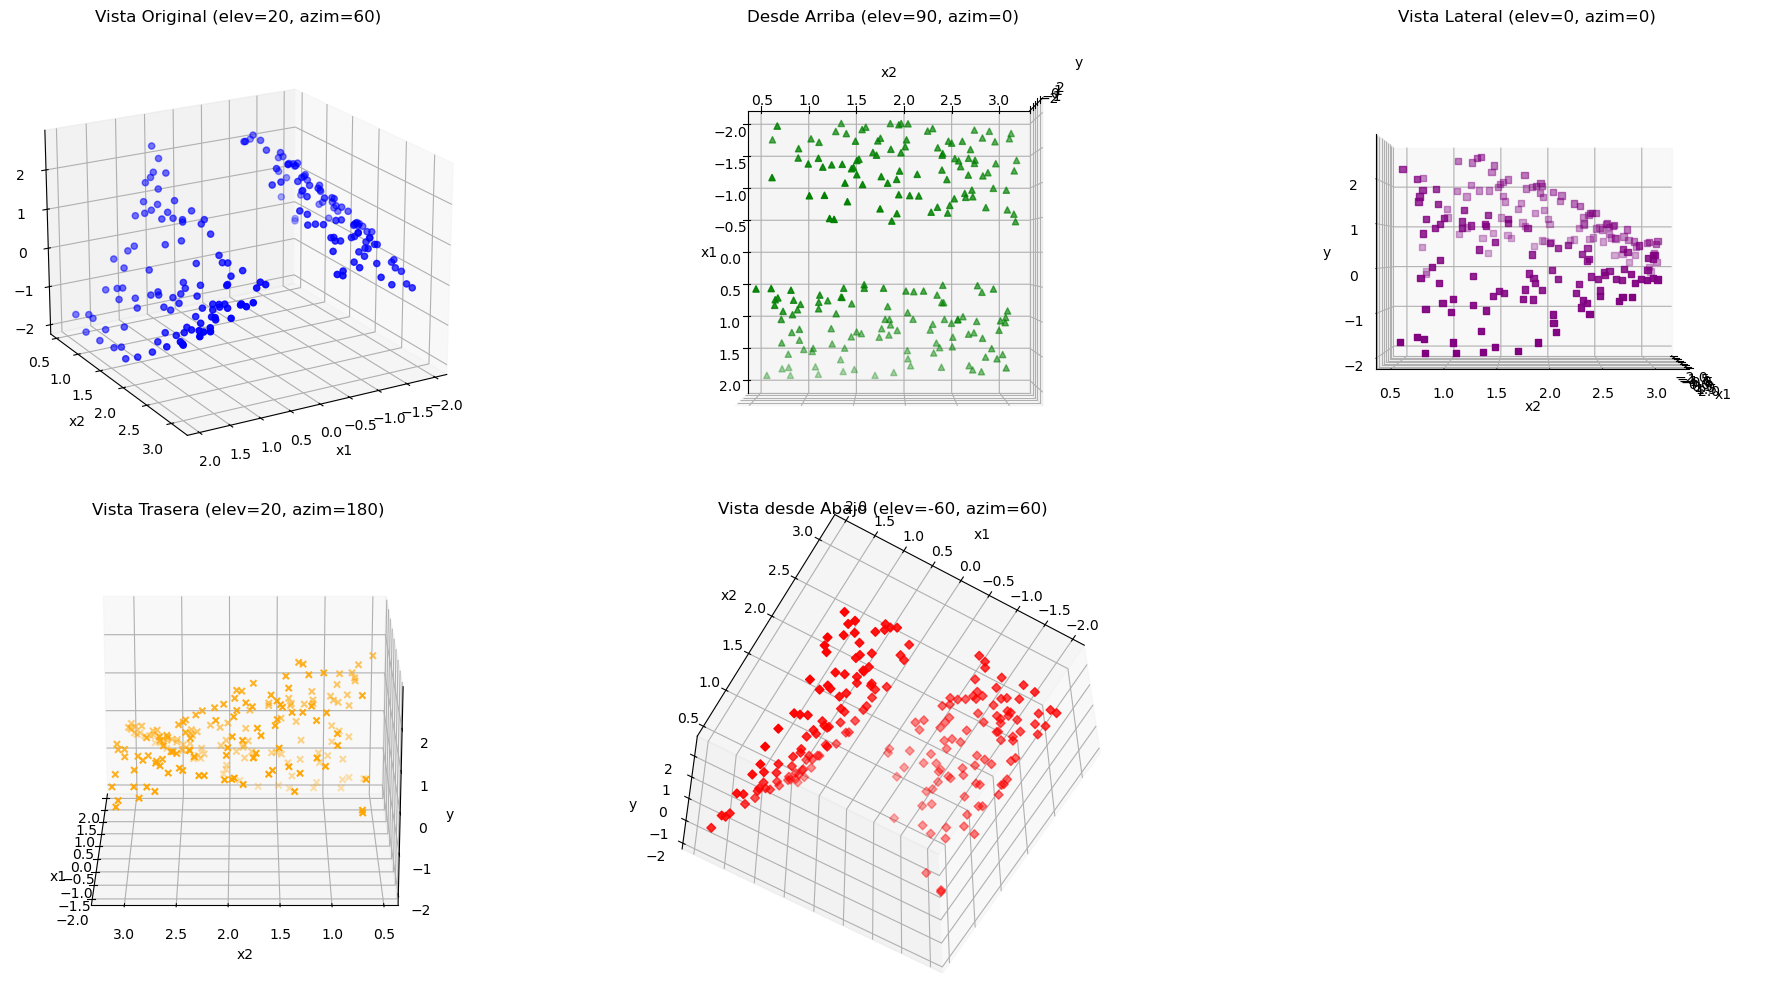

In [5]:
graficas_data(x_entrenamiento, y_entrenamiento)

## ¿Cómo están distribuidos los datos?

Se puede observar lo siguiente para los datos de entrenamiento:

- En la vista **original** (azul), y también desde **arriba** (verde), los datos parecen estar **segmentados en dos regiones**. Esto sugiere que la relación entre las variables $x_1$, $x_2$ y $y$ podría no ser completamente lineal ni homogénea en todo el espacio.
- La distribución dentro de cada segmento parece **bastante uniforme**. En las vistas **lateral** (morado) y **desde abajo** (rojo), se aprecia que los puntos están bien repartidos dentro de una especie de "plano inclinado", lo cual puede indicar que un modelo lineal podría capturar al menos parcialmente la tendencia en estas secciones.
- La vista **trasera** (naranja) impulsa la idea de una **superficie inclinada con dos zonas principales** de concentración de datos, lo que sugiere que tal vez haya una relación no lineal entre las variables.


## Datos de Validación

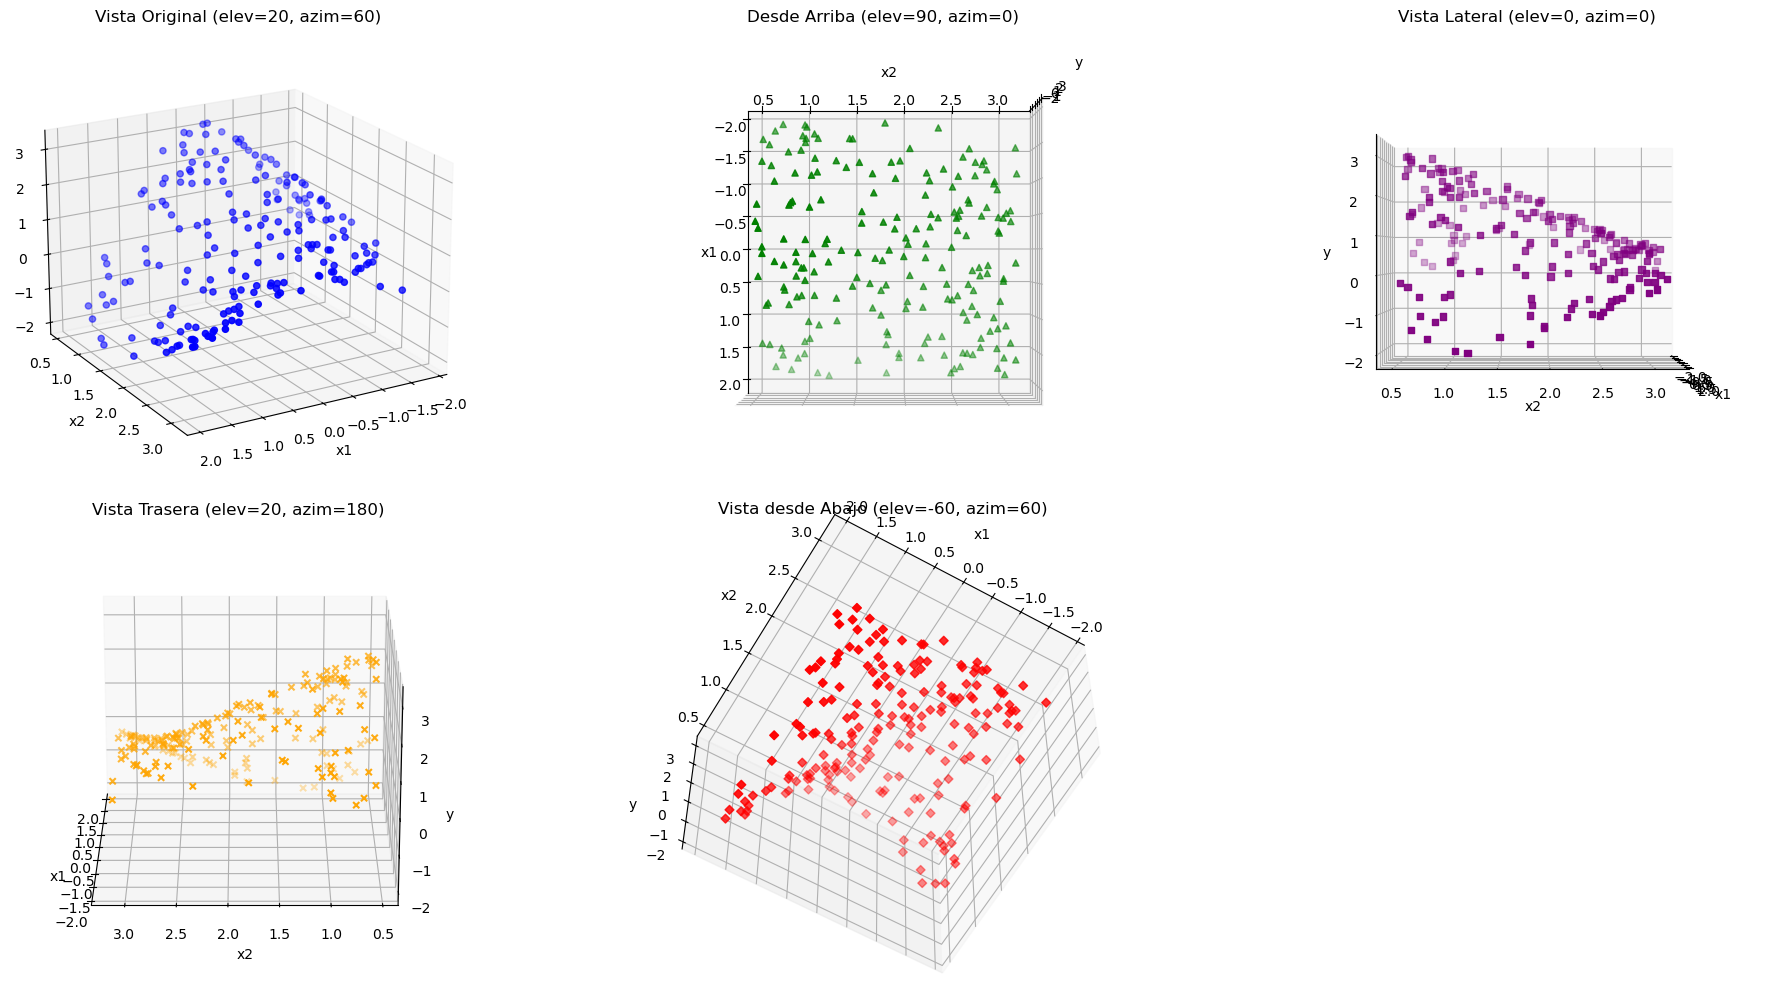

In [6]:
graficas_data(x_validacion, y_validacion)

## ¿Cómo están distribuidos los datos?

Se observa lo siguiente: 

- Los datos forman una **nube continua y suave** en el espacio $(x_1, x_2, y)$, sin que se aprecien agrupaciones o segmentos separados como con el conjunto de entrenamiento.
- La vista desde arriba (proyección sobre el plano $x_1$–$x_2$ de color verde) muestra que los puntos están **bien distribuidos** y cubren de manera uniforme el espacio de entrada.
- Desde la vista lateral, se observa una **pendiente descendente clara** entre la variable $x_2$ y la salida $y$, lo que sugiere una fuerte relación lineal negativa entre ambas.
- Otras vistas (inferior y trasera) muestran una posible **curvatura leve**, lo que indica que puede haber cierta **no linealidad suave** que no sería capturada completamente por un modelo lineal simple.

# **SOLUCIÓN b)**

In [7]:
# Entrenamos el modelo de regresión lineal (estimador de máxima verosimilitud)
modelo_lineal = LinearRegression()
modelo_lineal.fit(x_entrenamiento, y_entrenamiento)

# Obtenemos los parámetros del modelo
theta0 = modelo_lineal.intercept_
theta1, theta2 = modelo_lineal.coef_

print("-"*100)
print("Parámetros del modelo de regresión lineal (MLE):")
print("θ0 =", theta0)
print("θ1 =", theta1)
print("θ2 =", theta2)
print("-"*100)

# Realizamos predicciones para entrenamiento y validación
y_pred_entrenamiento = modelo_lineal.predict(x_entrenamiento)
y_pred_validacion = modelo_lineal.predict(x_validacion)

# Calculamos el Error Cuadrático Medio (MSE) para ambos conjuntos
mse_entrenamiento = mean_squared_error(y_entrenamiento, y_pred_entrenamiento)
mse_validacion = mean_squared_error(y_validacion, y_pred_validacion)

print("Error Cuadrático Medio (MSE) en Entrenamiento:", mse_entrenamiento)
print("Error Cuadrático Medio (MSE) en Validación:", mse_validacion)

----------------------------------------------------------------------------------------------------
Parámetros del modelo de regresión lineal (MLE):
θ0 = 1.0833295824645783
θ1 = -0.5461849484233429
θ2 = -0.3006249308482143
----------------------------------------------------------------------------------------------------
Error Cuadrático Medio (MSE) en Entrenamiento: 0.5896497098972882
Error Cuadrático Medio (MSE) en Validación: 0.8987307291283133


# **SOLUCIÓN c)**


#### Las siguientes dos celdas de tipo MarkDown son copia y pega de celdas del Problema 1 (el de los carros), las coloco aquí porque se usan los mismos métodos y me gusta dar un poco de contexto de lo que se está haciendo. 

## ¿Qué hace `PolynomialFeatures` y por qué usarlo en este inciso?

La clase `PolynomialFeatures(degree=d)` transforma las variables originales en una nueva matriz de características que contiene **todos los monomios posibles** hasta el grado `d`. Esto permite capturar relaciones **no lineales** usando modelos lineales.

---

#### Definición formal

Dado un vector de entrada:

$$
\mathbf{x} = [x_1, x_2, \dots, x_n]
$$

`PolynomialFeatures(degree=d)` genera todos los términos del tipo:

$$
x_1^{a_1} x_2^{a_2} \dots x_n^{a_n} \quad \text{tales que} \quad a_1 + a_2 + \dots + a_n \leq d
$$

Cada uno de estos términos se convierte en una nueva columna en la matriz de entrada transformada.

---

#### Ejemplo con dos variables:

Si se tiene $$ \mathbf{x} = [x_1, x_2] $$

- Grado 1:  
  $$
  [x_1, x_2]
  $$

- Grado 2:  
  $$
  [x_1, x_2, x_1^2, x_1 x_2, x_2^2]
  $$

- Grado 3:  
  $$
  [x_1, x_2, x_1^2, x_1 x_2, x_2^2, x_1^3, x_1^2 x_2, x_1 x_2^2, x_2^3]
  $$

---

#### Nota:

- Si `include_bias=True`, se incluye el término constante \( 1 \).
- En nuestro caso usamos `include_bias=False` para evitar duplicar el intercepto del modelo.

---

#### ¿Qué hace `.fit_transform(X)`?

La instrucción `poly.fit_transform(X)` aplica la transformación polinomial a **todas las filas** de la matriz `X`.

- Por cada fila (ejemplo), calcula todas las combinaciones de los atributos hasta el grado `d`
- Devuelve una **nueva matriz `X_poly`**, con el mismo número de filas, pero con muchas más columnas

## Mínimos cuadrados con penalización (Ridge)

En esta parte se realiza la regresión utilizando un **polinomio de grado 2** sobre los atributos, pero ahora se agrega un **término de penalización** que limita el tamaño de los coeficientes para evitar el sobreajuste.

---

#### Objetivo

- Aplicar **regresión polinomial de grado 2**.
- Incorporar **penalización por norma L2 (Ridge, [sklearn.linear_model.Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html))**.
- Evaluar el desempeño para diferentes valores del parámetro de regularización $ \lambda $ (llamado `alpha` en `scikit-learn`).
- Comparar el **Error Cuadrático Medio (MSE)** en entrenamiento y validación.

---

#### ¿Qué es la regularización?

Cuando el modelo tiene **muchas variables** (como ocurre al expandir a grado 20), puede aprender demasiado bien los datos de entrenamiento y fallar al generalizar. Esto se llama **sobreajuste**.

La regularización **agrega un castigo al tamaño de los coeficientes** $ \beta $, controlado por un parámetro $ \lambda $:

$$
\min_{\beta} \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \|\beta\|_2^2
$$

- **Ridge (L2)**: penaliza con la **norma cuadrada**  
  $$ \|\beta\|_2^2 = \sum \beta_i^2 $$

Esto ayuda a **reducir el sobreajuste** manteniendo todos los coeficientes pequeños pero distintos de cero.

In [8]:
grado = 2  # Definimos el grado del polinomio
expansion_polinomial = PolynomialFeatures(degree=grado, include_bias=True)

# Transformamos las variables de entrada a una base polinomial
x_entrenamiento_poly = expansion_polinomial.fit_transform(x_entrenamiento)
x_validacion_poly = expansion_polinomial.transform(x_validacion)

# Entrenamos el modelo Ridge con regularización L2 (alpha=1.0)
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(x_entrenamiento_poly, y_entrenamiento)

# Mostramos los parámetros del modelo
print("-"*100)
print("Parámetros del modelo Ridge (grado 2, regularización L2):")
print("Intersección (θ0):", modelo_ridge.intercept_)
print("Coeficientes:", modelo_ridge.coef_)
print("-"*100)

# Realizamos predicciones con el modelo entrenado
y_pred_entrenamiento_ridge = modelo_ridge.predict(x_entrenamiento_poly)
y_pred_validacion_ridge = modelo_ridge.predict(x_validacion_poly)

# Calculamos el MSE en entrenamiento y validación
mse_entrenamiento_ridge = mean_squared_error(y_entrenamiento, y_pred_entrenamiento_ridge)
mse_validacion_ridge = mean_squared_error(y_validacion, y_pred_validacion_ridge)

print("Error Cuadrático Medio (MSE) con modelo Ridge en Entrenamiento:", mse_entrenamiento_ridge)
print("Error Cuadrático Medio (MSE) con modelo Ridge en Validación:", mse_validacion_ridge)

----------------------------------------------------------------------------------------------------
Parámetros del modelo Ridge (grado 2, regularización L2):
Intersección (θ0): 2.2199906557019107
Coeficientes: [ 0.         -0.9370307  -0.34594232 -0.61396247  0.1695568  -0.0047964 ]
----------------------------------------------------------------------------------------------------
Error Cuadrático Medio (MSE) con modelo Ridge en Entrenamiento: 0.15289822433213796
Error Cuadrático Medio (MSE) con modelo Ridge en Validación: 0.2388547150498522


# **SOLUCIÓN EXTRA**

### Advertencia de mucho texto, jiji, pero me parece buena idear saber qué estamos proponiendo y haciendo.

## ¿Qué estamos haciendo en este problema extra?

---

### El contexto

En este problema, trabajamos con un modelo de regresión lineal simple de la forma:

$$
f(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2
$$

Sin embargo, a diferencia del enfoque clásico (que busca un único conjunto óptimo de parámetros $ \theta $), en la **regresión lineal bayesiana**, tratamos a los parámetros como **variables aleatorias**: no sabemos sus valores exactos, pero creemos que están en una región probable del espacio de parámetros.

---

### ¿Por qué tratarlos como variables aleatorias?

Porque antes de observar datos, no tenemos certeza sobre qué valores deberían tomar los parámetros. Por ello, usamos un **prior**:

> Nuestra creencia inicial es que $ \theta \sim \mathcal{N}(0, I) $, es decir, todos los parámetros tienen media cero, varianza 1 y no están correlacionados.

Después, al observar datos, aplicamos el **teorema de Bayes** para actualizar nuestra creencia y obtener una **distribución a posteriori** sobre los parámetros. Esto nos da una nueva forma de ver el aprendizaje:

> En vez de decir “estos son los parámetros correctos”, decimos “estos son los más probables dadas las evidencias”.

---

### ¿Qué generamos paso a paso?

#### 1. Usamos distintos tamaños de conjuntos de datos:  
$$ n \in \{5, 10, 30, 60\} $$

Tomamos subconjuntos pequeños del entrenamiento para estudiar cómo cambia nuestra certeza sobre los parámetros a medida que tenemos más información.

---

#### 2. Calculamos la distribución **a posteriori** de los parámetros $ \theta $

Esta distribución es de la forma:

$$
\theta \mid X, y \sim \mathcal{N}(\mu_N, \Sigma_N)
$$

- La **media $ \mu_N $** nos dice cuáles son los parámetros más probables.
- La **covarianza $ \Sigma_N $** nos dice cuánta incertidumbre hay en cada dirección (parámetro).

---

#### 3. Generamos 20 muestras de parámetros $ \theta $

Usamos la distribución a posteriori para generar 20 posibles vectores de parámetros $ \theta $.  
Cada uno representa un modelo distinto **consistente con los datos**.

Por ejemplo:
- Un modelo puede decir: $ y = 1 + 0.5x_1 - 0.2x_2 $
- Otro podría decir: $ y = 0.2 + 0.1x_1 + 0.9x_2 $

Y ambos son válidos desde la perspectiva bayesiana, dados los datos observados.

---

#### 4. Graficamos las curvas de predicción

Cada muestra de $ \theta $ se utiliza para generar una curva de predicción sobre los datos de entrada.  
Las **20 curvas resultantes se grafican juntas**, permitiéndonos visualizar:

- Qué tan diferentes podrían ser los modelos que explican los datos
- Cuánta incertidumbre tiene el modelo en cada zona del espacio

---

#### 5. Calculamos la predicción para un nuevo punto $ \tilde{x} = [1, 2] $

En vez de dar una única predicción, el enfoque bayesiano nos da una **distribución predictiva**:

- Una **media esperada**: qué valor creemos que tomará $ y $
- Una **varianza**: cuánta confianza tenemos en esa predicción

Esto es muy poderoso: podemos decir, por ejemplo:

> “La salida esperada es 5.1, pero podría estar entre 4.8 y 5.4, con un 95% de confianza”

### Paso 1: Función para obtener la distribución a posteriori

En la regresión lineal bayesiana, no buscamos un único vector de parámetros $\theta$ (como en la regresión clásica), sino una **distribución de probabilidad sobre los posibles valores de $\theta$**, basada en los datos observados.

#### Supuestos bayesianos

Partimos de un **prior** sobre los parámetros:

- Suponemos que los parámetros $\theta = [\theta_0, \theta_1, \theta_2]^\top$ están distribuidos según una **distribución normal multivariada**:

$$
\theta \sim \mathcal{N}(0, I)
$$

Es decir, creemos *a priori* que cada parámetro tiene media cero e incertidumbre (varianza 1), y que no hay correlación entre ellos (covarianza identidad).

---

#### ¿Qué pasa cuando observamos datos?

Cuando observamos un conjunto de datos $\mathcal{D} = \{X, y\}$, actualizamos nuestra creencia mediante el **teorema de Bayes**:

$$
p(\theta \mid X, y) \propto p(y \mid X, \theta) \cdot p(\theta)
$$

Este cálculo da como resultado una nueva distribución llamada **distribución a posteriori**, que también resulta ser una distribución normal:

- **Media posterior**:

$$
\mu_N = \Sigma_N X^\top y
$$

- **Covarianza posterior**:

$$
\Sigma_N = (X^\top X + I)^{-1}
$$

Esto se deriva de una combinación algebraica entre el prior y la verosimilitud de los datos.

La siguiente función devuelve los parámetros de la distribución a posteriori para poder:

    -Predecir con incertidumbre

    -Generar muestras del modelo

    -Visualizar la dispersión de posibles regresores

In [9]:
def bayesian_linear_regression_posterior(X, y):
    """
    Calcula la distribución a posteriori de los parámetros en regresión lineal bayesiana.

    Se asume un prior gaussiano sobre los parámetros:
        θ ~ N(0, I)

    Dado un conjunto de datos X, y, esta función devuelve la media (mu_N) y la matriz 
    de covarianza (Sigma_N) de la distribución a posteriori:

        θ | X, y ~ N(mu_N, Sigma_N)

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Matriz de diseño con las variables predictoras, incluyendo el término de sesgo (bias).
    y : ndarray of shape (n_samples,)
        Vector de respuestas (targets).

    Returns
    -------
    mu_N : ndarray of shape (n_features,)
        Media de la distribución a posteriori de los parámetros.
    Sigma_N : ndarray of shape (n_features, n_features)
        Matriz de covarianza de la distribución a posteriori.
    """

    n_features = X.shape[1]              # Número de características (incluyendo el bias)
    I = np.eye(n_features)               # Matriz identidad del mismo tamaño (para el prior)

    # Covarianza a posteriori: (XᵗX + I)⁻¹
    Sigma_N = np.linalg.inv(X.T @ X + I)

    # Media a posteriori: Σ_N Xᵗ y
    mu_N = Sigma_N @ X.T @ y

    return mu_N, Sigma_N

### Paso 2: Vector de predicción $ \tilde{x} = [1, 2] $

En este paso, se define el vector de entrada $ \tilde{x} $ para el cual queremos conocer la **distribución predictiva** de la salida.

Dado que nuestro modelo incluye un **término de sesgo** $ \theta_0 $, necesitamos extender el vector $ \tilde{x} $ con un 1 al inicio, formando:

$$
\tilde{x} = [1, 1, 2]^\top
$$

Esto permite aplicar directamente las fórmulas para media y varianza predictiva en regresión lineal bayesiana:

- Media: $ \tilde{x}^\top \mu_N $
- Varianza: $ \tilde{x}^\top \Sigma_N \tilde{x} $

In [10]:
# Vector para predecir: x̃ = [1, 2]
x_tilde = np.array([1, 2])
X_tilde = np.insert(x_tilde, 0, 1)  # Incluimos el bias (θ0)

### Paso 3: Función para calcular la distribución predictiva

Una vez obtenida la distribución a posteriori de los parámetros $ \theta $, podemos calcular la **distribución predictiva** de la salida para una nueva entrada $ \tilde{x} $.

En regresión lineal bayesiana, la predicción para $ \tilde{x} $ no es un valor puntual, sino una **distribución gaussiana** con:

- **Media**:
  $$
  \mathbb{E}[y \mid \tilde{x}] = \tilde{x}^\top \mu_{N}
  $$

- **Varianza**:
  $$
  \mathrm{Var}[y \mid \tilde{x}] = \tilde{x}^\top \Sigma_{N} \tilde{x}
  $$

Esto refleja tanto la incertidumbre del modelo como la del dato.

In [11]:
def predictive_distribution(X_tilde, mu_N, Sigma_N):
    """
    Calcula la media y varianza de la distribución predictiva
    para un nuevo punto X_tilde usando la posterior de θ.

    Parameters
    ----------
    X_tilde : ndarray of shape (n_features,)
        Vector de entrada (incluyendo el bias θ0).
    mu_N : ndarray of shape (n_features,)
        Media de la distribución a posteriori de θ.
    Sigma_N : ndarray of shape (n_features, n_features)
        Covarianza de la distribución a posteriori de θ.

    Returns
    -------
    mean : float
        Media de la distribución predictiva.
    var : float
        Varianza de la distribución predictiva.
    """
    mean = X_tilde @ mu_N                  # Producto escalar: media de la predicción
    var = X_tilde @ Sigma_N @ X_tilde.T    # Producto cuadrático: varianza de la predicción
    return mean, var

### Paso 4: Visualización de la distribución a posteriori y predicciones generadas

En este paso se analiza cómo varía la **distribución a posteriori de los parámetros** y las **predicciones del modelo** conforme se utilizan distintos tamaños de muestra:  
$n \in \{5, 10, 30, 60\}$

---

#### ¿Qué se hace?

1. Para cada cantidad de datos utilizada:
   - Se seleccionan los primeros $n$ datos de entrenamiento.
   - Se calcula la distribución a posteriori de los parámetros $\theta$ como una normal multivariada:
     $$
     \theta \mid X, y \sim \mathcal{N}(\mu_N, \Sigma_N)
     $$
   - Se generan **20 muestras aleatorias** de posibles valores de $\theta$ a partir de esa distribución.
   - Para cada muestra de $\theta$, se calcula la curva de predicción correspondiente (es decir, cómo se vería el modelo si esos fueran los verdaderos parámetros).

2. Se grafica el conjunto de **20 curvas de predicción** sobre los datos usados para entrenar (cada curva representa un modelo posible).

3. También se evalúa la **distribución predictiva** para un nuevo punto específico $\tilde{x} = [1, 2]$, reportando su:
   - Media esperada $\mathbb{E}[y \mid \tilde{x}]$
   - Varianza $\text{Var}[y \mid \tilde{x}]$

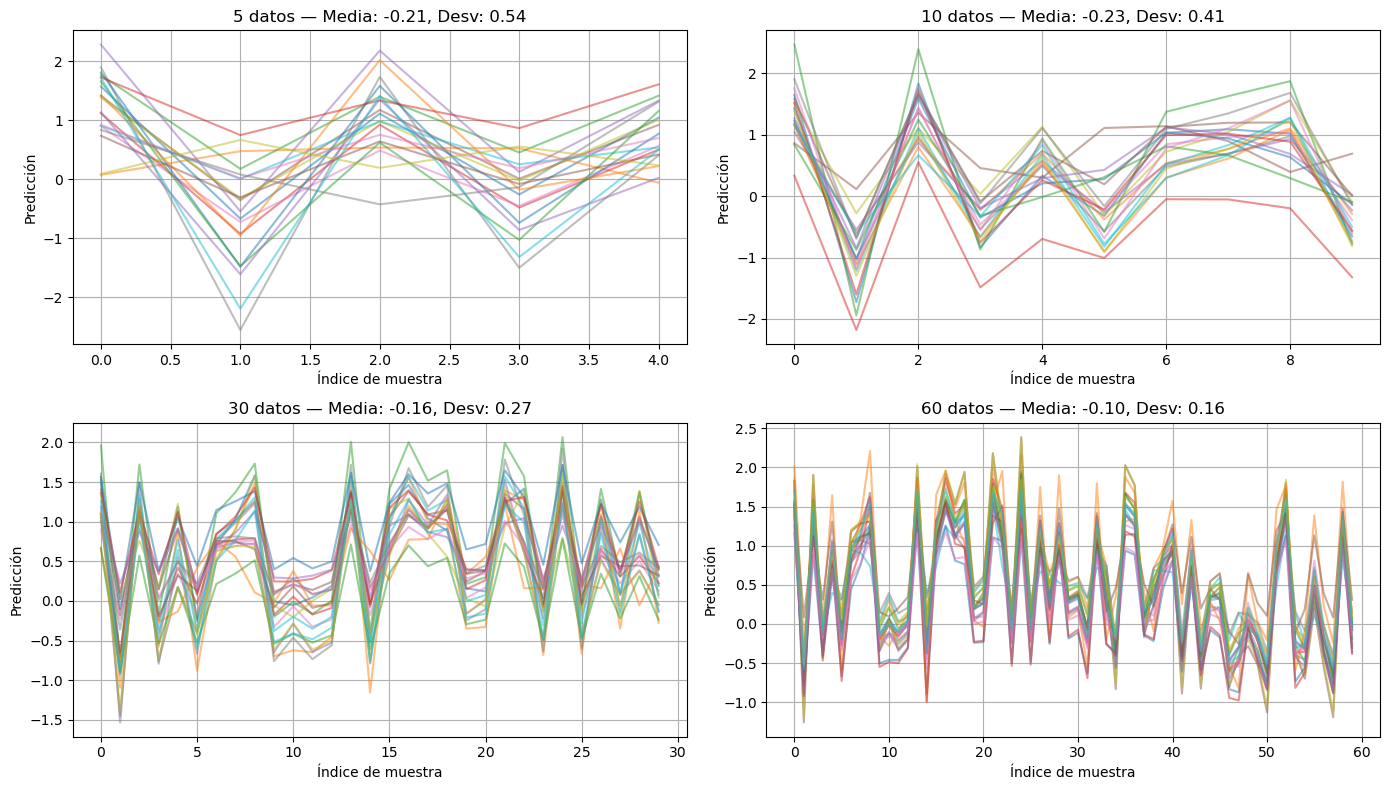

In [12]:
# Subconjuntos de tamaños
tamaños = [5, 10, 30, 60]

# Copiamos los datos y añadimos columna de bias (θ0)
x_data = x_entrenamiento.copy()
x_data.insert(0, 'bias', 1)

# Creamos los subplots 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
axs = axs.ravel()  # Para acceder como lista lineal

for i, n in enumerate(tamaños):
    # Subconjunto de datos
    X_n = x_data.iloc[:n].values
    y_n = y_entrenamiento[:n]

    # Posterior bayesiana
    mu_N, Sigma_N = bayesian_linear_regression_posterior(X_n, y_n)

    # 20 muestras de θ
    muestras = multivariate_normal(mu_N, Sigma_N, size=20)

    # Curvas generadas
    for theta in muestras:
        y_curve = X_n @ theta
        axs[i].plot(y_curve, alpha=0.5)

    # Distribución predictiva para x̃ = [1, 2]
    media, varianza = predictive_distribution(X_tilde, mu_N, Sigma_N)
    desviacion = np.sqrt(varianza)

    # Configuraciones del subplot
    axs[i].set_title(f"{n} datos — Media: {media:.2f}, Desv: {desviacion:.2f}")
    axs[i].set_xlabel("Índice de muestra")
    axs[i].set_ylabel("Predicción")
    axs[i].grid(True)

# Ajustamos el espaciado
plt.tight_layout()
plt.show()


#### ¿Qué observamos y por qué es importante?

- A medida que aumentamos el tamaño de la muestra $n$, la **dispersión de las curvas disminuye**. Esto se debe a que el modelo gana más certeza sobre cuáles son los parámetros más probables.
- Cuando $n = 5$, las curvas son muy variadas entre sí → mucha incertidumbre (los parámetros posibles están muy dispersos).
- Cuando $n = 60$, las curvas tienden a agruparse → menor incertidumbre (los parámetros convergen).
- La **varianza predictiva también disminuye**, lo que significa que el modelo está más seguro de sus predicciones para puntos nuevos como $\tilde{x}$.

Esto muestra de forma visual cómo el enfoque **bayesiano no da una única respuesta**, sino un conjunto de modelos posibles, cuya dispersión refleja cuánta información tenemos.

# **DISCUSIÓN Y CONCLUSIONES**

### Rendimiento de los modelos

- **Regresión lineal clásica (MLE):**
  - MSE Entrenamiento: 0.59  
  - MSE Validación: 0.89  
  - Aunque el modelo logra una aproximación buena, el error en validación sugiere una capacidad baja para generalizar.

- **Regresión Ridge (polinomio de grado 2 con regularización L2):**
  - MSE Entrenamiento: 0.15  
  - MSE Validación: 0.23  
  - Este modelo mejora mucho el desempeño al capturar relaciones no lineales con bajo sobreajuste, lo que se puede apreciar en la diferencia menor entre entrenamiento y validación.

---

### Incertidumbre y comportamiento bayesiano

- Las curvas generadas a partir de 20 muestras de la distribución a posteriori muestran que:
  - Con **5 datos**, la varianza es alta y las curvas son muy dispersas (Desv: 0.54).
  - Con **10 y 30 datos**, la incertidumbre disminuye poco a poco.
  - Con **60 datos**, las curvas están más concentradas y coherentes entre sí (Desv: 0.16), indicando mayor confianza en las predicciones.

Esto demuestra que el enfoque bayesiano no solo produce predicciones, sino que también permite cuantificar la **confianza del modelo** en función de la cantidad de datos observados.

---

### Distribución de los datos

- Las vistas 3D indican que los datos están distribuidos de forma **continua y sin divisiones claras**, lo que sugiere que no existen subgrupos ocultos o clases separadas.
- Se observa una relación **lineal entre $x_2$ y $y$**, y posiblemente una **curvatura suave**, lo cual explica por qué un modelo polinomial mejora el ajuste.

---

### Conclusión final

- La regresión lineal **clásica es suficiente** para captar la tendencia general, pero **no ofrece la mejor generalización**.
- La regresión **polinomial con regularización** logra **mejor ajuste y menor error**, lo que la convierte en la mejor opción.
- El enfoque **bayesiano** ofrece la ventaja de **medir la incertidumbre**, y su comportamiento mejora al incrementar el número de observaciones.

Cada enfoque aporta una perspectiva distinta:
- **Precisión:** Ridge
- **Simplicidad:** MLE
- **Incertidumbre y robustez:** Bayesiano

Es bueno explorar múltiples modelos al abordar un problema de regresión.